## What is an Autoencoder?

The term autoencoder originates from two parts:
1. **Auto:** self
2. **Encoder:** to convert into a different form, usually simpler or reduced in dimensionality.

An autoencoder is essentially **a system or neural network that learns to teach itself** how to encode information efficiently.

An **autoencoder** is a type of neural network trained to reconstruct its input data at the output layer. Its main objective is to learn a compressed representation of the input, often used for dimensionality reduction or unsupervised learning tasks.
$$
or
$$

An **autoencoder** is a neural network designed to learn a compressed representation (encoding) of input data so that the input can be approximately reconstructed from this compressed code. The network achieves this by minimizing the reconstruction error between input and output.

- It is an **unsupervised learning algorithm** because it learns to **replicate input data without explicit target labels**.
- Training uses **backpropagation** to minimize the difference between the input and output (**reconstruction loss**).

#### Applications

Autoencoders have diverse applications, including:

1. **Dimensionality Reduction:** Compress high-dimensional data into meaningful lower dimensions.
2. **Noise Removal:** Denoising autoencoders filter noise from corrupted input data.
3. **Anomaly Detection:** Detect unusual patterns by measuring reconstruction errors.
4. **Generative Models:** Variational autoencoders generate new data samples similar to the training set.

### Architecture of Autoencoders

Autoencoders consist of two key parts:

1. **Encoder**: Maps the input data $ \mathbf{x} $ to a compressed latent representation $ \mathbf{z} $.  The encoder typically reduces **the dimensionality of the input data** $ \mathbf{x} $ to produce a latent vector $ \mathbf{z} $. Formally:
   $$
   \mathbf{z} = f_{\text{encoder}}(\mathbf{x})
   $$
   where $ \mathbf{z} $ is a lower-dimensional vector capturing the most important features.

2. **Decoder**: The decoder reconstructs the original data $ \hat{\mathbf{x}} $ from the latent vector $ \mathbf{z} $, which is a reduced representation of $ \hat{\mathbf{x}} $. Reconstructs the original input $ \hat{\mathbf{x}} $ from the latent vector $ \mathbf{z} $:
   $$
   \hat{\mathbf{x}} = f_{\text{decoder}}(\mathbf{z})
   $$

The network is trained to minimize the reconstruction error (Mean Squared Error):
$$
\mathcal{L}(\mathbf{x}, \hat{\mathbf{x}}) = \| \mathbf{x} - \hat{\mathbf{x}} \|^2
$$

### Weight Sharing and Biases

- Autoencoders can implement **shared weights** where decoder weights are the transpose of encoder weights, reducing parameters and overfitting.
- Shared weights act as **implicit regularization**, reducing overfitting.
- **Separate bias terms** are maintained for hidden and output layers.

### Types of Autoencoders



- **Single-Layer Autoencoder**: Shown as a simple bottleneck structure with one encoding and one decoding layer.
- **Stacked Autoencoder**: Composed of multiple layers in both encoder and decoder parts, allowing deeper feature extraction, Heirarchial representations and more complex representations.

In [ ]:
import keras
from keras.layers import Input, Dense
from keras.models import Model, Sequential

import pandas as pd

In [ ]:
# Load data
train_data = pd.read_csv('/content/sample_data/mnist_train_small.csv')
train_data.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_data.columns

Index(['6', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8',
       ...
       '0.581', '0.582', '0.583', '0.584', '0.585', '0.586', '0.587', '0.588',
       '0.589', '0.590'],
      dtype='object', length=785)

In [ ]:
train_data.shape[1]

785

In [ ]:
col_names = []
for i in range(train_data.shape[1]):
  col_names.append(f'pixel_{i}')
col_names[0] = 'target'
train_data.columns = col_names

In [ ]:
train_data.head()

,target,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,pixel_784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_train = train_data.drop('target', axis = 1)
X_train.head()

,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,...,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,pixel_784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y_train = train_data['target']
y_train.head()

,target
0,5
1,7
2,9
3,5
4,2


In [ ]:
col_names = []
for i in range(test_data.shape[1]):
  col_names.append(f'pixel_{i}')
col_names[0] = 'target'
test_data.columns = col_names

In [ ]:
test_data = pd.read_csv('/content/sample_data/mnist_test.csv')
test_data.head()

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_test = test_data.drop('target', axis = 1)
X_test.head()

,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,...,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,pixel_784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y_test = test_data['target']
y_test.head()

,target
0,2
1,1
2,0
3,4
4,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
minmax = MinMaxScaler().set_output(transform = 'pandas')
minmax

MinMaxScaler()

In [ ]:
X_train_transformed = minmax.fit_transform(X_train)
X_train_transformed.head()

,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,...,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,pixel_784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Input dimension
input_dim = X_train_transformed.shape[1]  # e.g., flattened 28x28 image
input_dim

784

In [ ]:
# Latent dimension (compressed size)
latent_dim = 64

````
# Autoencoder
autoencoder = Sequential([
    # Encoder Layers
    Input(shape=(input_dim,)),
    Dense(128, activation='relu'),
    Dense(latent_dim, activation='relu'),
    # Decoder Layers
    Dense(128, activation='relu'),
    Dense(input_dim, activation='sigmoid')
])
autoencoder.summary()
````

In [ ]:
X_input = Input(shape=(input_dim,))
# Encoder Layers
encoder = Dense(128, activation='relu')(X_input)
latent = Dense(latent_dim, activation='relu')(encoder)
# Decoder Layers
decoder = Dense(128, activation='relu')(latent)
X_output = Dense(input_dim, activation='sigmoid')(decoder)
autoencoder = Model(inputs = X_input, outputs = X_output)
autoencoder.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model
autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
# Train autoencoder
history = autoencoder.fit(X_train_transformed,
                          X_train_transformed,
                          epochs=10,
                          batch_size=32,
                          shuffle=True,
                          validation_split = 0.2
                          )

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0692 - val_loss: 0.0225
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0201 - val_loss: 0.0149
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0143 - val_loss: 0.0123
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0119 - val_loss: 0.0109
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0104 - val_loss: 0.0099
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0095 - val_loss: 0.0092
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0088 - val_loss: 0.0087
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0083 - val_loss: 0.0083
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0079 - val_loss: 0.0079
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0075 - val_loss: 0.0078


In [ ]:
import matplotlib.pyplot as plt

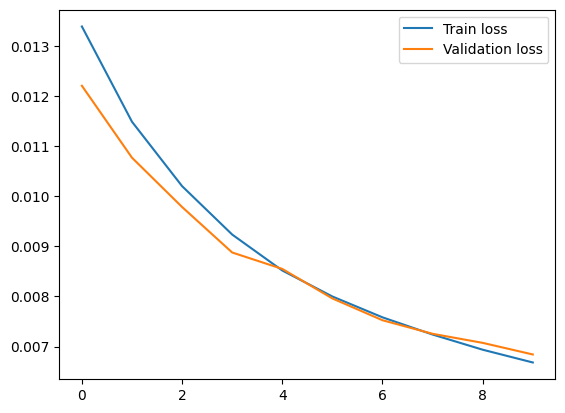

In [ ]:
plt.plot(history.history['loss'], label = 'Train loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.legend()
plt.show()

In [ ]:
X_test_transformed = minmax.transform(X_test)

In [ ]:
autoencoder.evaluate(x = X_test_transformed, y = X_test_transformed)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0074


0.0076487078331410885

## Autoencoders: Dimensionality Reduction

  - **A nonlinear method for dimensionality reduction**

Dimensionality reduction is the process of **transforming high-dimensional data into a lower-dimensional space while retaining important features as much as possible**.
- This helps in **removing**
  - redundant information,
  - reducing noise, and
  - making data easier to visualize and process.

An **autoencoder** is a type of neural network designed to learn an **efficient compressed representation (encoding)** of input data, **which makes it well-suited for dimensionality reduction**.

- **Encoder:** *Compresses* the input $ \mathbf{x} \in \mathbb{R}^D $ into a lower-dimensional latent space $ \mathbf{z} \in \mathbb{R}^d $, where $ d < D $.
- **Decoder:** *Reconstructs* the original data $ \hat{\mathbf{x}} $ from the compressed latent vector $ \mathbf{z} $.

- Once trained, the **encoder part can be used to transform new data into low-dimensional embeddings** usable in downstream tasks.

The network is **trained to minimize the reconstruction error**, ensuring the latent space captures the most salient features.

#### Autoencoders Are Nonlinear Extensions of PCA



- PCA performs **linear dimensionality reduction** by projecting data onto principal components. Unlike PCA (a linear method), autoencoders can **model more intricate data structures.**
- Autoencoders generalize this by learning **nonlinear mappings**, making them more flexible.
- Autoencoders can **learn nonlinear transformations**, capturing complex relationships in data.
- Without nonlinear activation functions (like sigmoid), autoencoders approximate PCA.
- Can also be stacked with multiple layers to form deep autoencoders for powerful feature extraction.

In [ ]:
import numpy as np
import keras
import tensorflow as tf
from keras.datasets import mnist
from keras.layers import Input, Dense, Dropout
from keras.models import Model, Sequential
from keras.optimizers import Adam
from keras.regularizers import L2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.
X_train.shape, X_test.shape
# Flatten images
X_train_transformed = X_train.reshape((len(X_train), np.prod(X_train.shape[1:])))
X_test_transformed = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))
X_train_transformed.shape, X_test_transformed.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((60000, 784), (10000, 784))

````
# NOT USEFUL FOR AUTOENCODERS - decoder weights are the transpose of encoder weights
autoencoder = Sequential(
    [
        # Encoder layers
        Input(batch_shape=(None, X_train_transformed.shape[1])),
        Dense(300, activation='relu'),
        Dropout(0.5),
        Dense(100, activation='relu'),
        Dropout(0.5),
        Dense(2, activation='linear', activity_regularizer=L2(0.01)),
        # Decoder layers
        Dense(100, activation='relu'),
        Dropout(0.5),
        Dense(300, activation='relu'),
        Dropout(0.5),
        Dense(X_train_transformed.shape[1], activation='sigmoid')
    ]
)
autoencoder.summary()
````

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Encoder layers
X_input = Input(batch_shape=(None, X_train_transformed.shape[1]))
encoder = Dense(300, activation='relu')(X_input)
encoder = Dropout(0.5)(encoder)
encoder = Dense(100, activation='relu')(encoder)
encoder = Dropout(0.5)(encoder)
latent = Dense(2, activation='linear', activity_regularizer=L2(0.01))(encoder)
# Decoder layers
decoder = Dense(100, activation='relu')(latent)
decoder = Dropout(0.5)(decoder)
decoder = Dense(300, activation='relu')(decoder)
decoder = Dropout(0.5)(decoder)
X_output = Dense(X_train_transformed.shape[1], activation='sigmoid')(decoder)
autoencoder = Model(inputs = X_input, outputs = X_output)
encoder = Model(inputs = X_input, outputs = latent)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           202 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │        30,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       235,984 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,386 (2.03 MB)

 Trainable params: 532,386 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile Model
autoencoder.compile(loss='binary_crossentropy',
                    optimizer = Adam(learning_rate=0.001))

In [ ]:
# Training
hist = autoencoder.fit(x = X_train_transformed,
                       y = X_train_transformed,
                       epochs=300,
                       batch_size=256,
                       validation_data = (X_test_transformed, X_test_transformed))

Epoch 1/300
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - loss: 0.6232 - val_loss: 0.2630
Epoch 2/300
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2660 - val_loss: 0.2628
Epoch 3/300
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2649 - val_loss: 0.2626
Epoch 4/300
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2642 - val_loss: 0.2594
Epoch 5/300
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2609 - val_loss: 0.2481
Epoch 6/300
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2520 - val_loss: 0.2429
Epoch 7/300
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2478 - val_loss: 0.2411
Epoch 8/300
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2454 - val_loss: 0.2392
Epoch 9/300
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2437 - val_loss: 0.2380
Epoch 10/300
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2425 - val_loss: 0.2371
Epoch 11/300
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2415 - val_loss: 0.2362
Epoch 12/300
235/235 ━━━━━━━━━━━━━━━━━━

In [ ]:
# Fitting graph
plt.plot(hist.history['loss'], c='blue', label='train loss')
plt.plot(hist.history['val_loss'], c='red', label='test loss')
plt.legend()
plt.show()

In [ ]:
# Reduce the dimensionality of the test data.
X_pred = encoder.predict(X_test_transformed)

In [ ]:
# z-space
def show_image(x, y):
    plt.figure(figsize=(6,6))
    for i in np.unique(y):
        idx = np.where(y == i)[0]
        z = x[idx]
        plt.scatter(z[:, 0], z[:, 1], s=10, alpha=0.5, label=str(i))
    plt.legend()
    plt.show()

In [ ]:
print('\nDimensionality reduction by Autoencoder', end='')
show_image(X_pred, y_test)

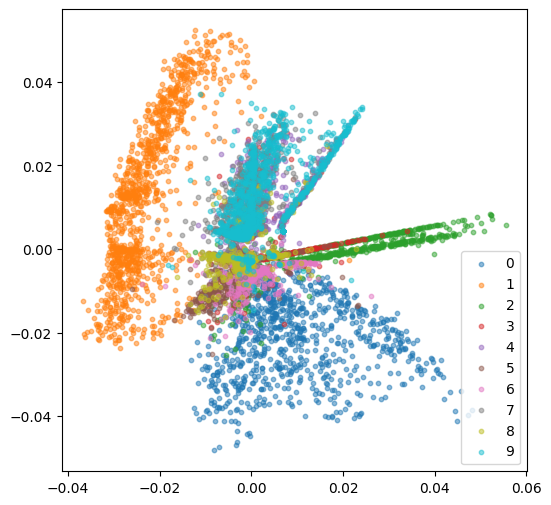

In [ ]:
autoencoder.save_weights('/content/saved_weights.weights.h5')

#### Dimensionality Reduction using Kernel PCA

In [ ]:
from sklearn.decomposition import KernelPCA

In [ ]:
X_train_transformed.shape

(60000, 784)


Dimensionality reduction by PCA

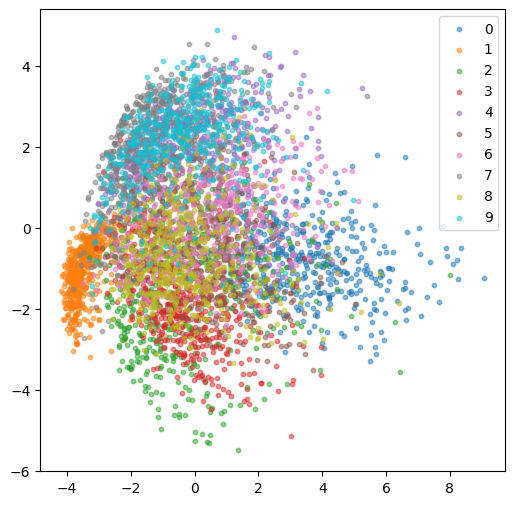

In [ ]:
x_train1 = X_train_transformed[:10000]
x_test1 = X_test_transformed[:5000]
y_test1 = y_test[:5000]

pca = KernelPCA(n_components=2)
pca.fit(x_train1)
x_pred_pca = pca.transform(x_test1)

print('\nDimensionality reduction by PCA', end='')
show_image(x_pred_pca, y_test1)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, BatchNormalization, Flatten
from keras.optimizers import SGD, Adagrad, RMSprop, Adam

Load the data

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [ ]:
image_batch = np.expand_dims(X_train[:9], axis = -1)
image_batch.shape

(9, 28, 28, 1)

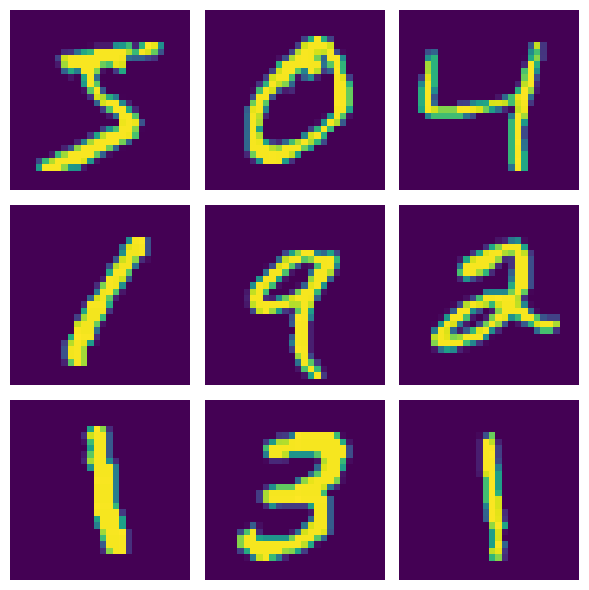

In [ ]:
keras.visualization.plot_image_gallery(image_batch)

Image data Preprocessing - Normalization

In [ ]:
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

Build a Autoencoder - Optimizer as SGD

In [ ]:
# Encoder layers
X_input = Input(shape=(28, 28, 1))
encoder = Flatten()(X_input)
latent = Dense(64, activation="relu")(encoder)

# Decoder layers
decoder = Dense(64, activation="relu")(latent)
decoder = Dense(784, activation="relu")(decoder)
X_output = keras.layers.Reshape((28, 28, 1))(decoder)

# Encoder Model
encoder = Model(inputs = X_input, outputs = latent)

# Autoencoder model
autoencoder = Model(inputs = X_input, outputs = X_output)

# Compile the model
autoencoder.compile(loss='mean_squared_error', optimizer = SGD())

autoencoder.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,360 (411.56 KB)

 Trainable params: 105,360 (411.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = autoencoder.fit(X_train,
                          X_train,
                          batch_size=128,
                          epochs=50,
                          validation_split = 0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1065 - val_loss: 0.1047
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1052 - val_loss: 0.1031
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1035 - val_loss: 0.1011
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1014 - val_loss: 0.0988
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0990 - val_loss: 0.0962
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0963 - val_loss: 0.0935
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0935 - val_loss: 0.0907
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0907 - val_loss: 0.0881
Epoch 9/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0880 - val_loss: 0.0856
Epoch 10/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0855 - val_loss: 0.0834
Epoch 11/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0834 - val_loss: 0.0815
Epoch 12/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

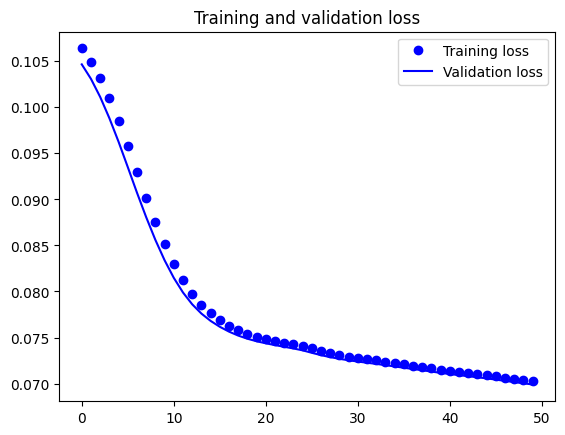

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(50)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Images


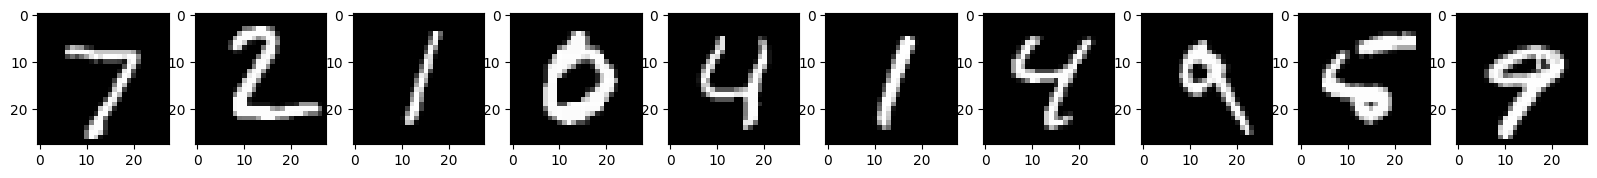

Compressed Image


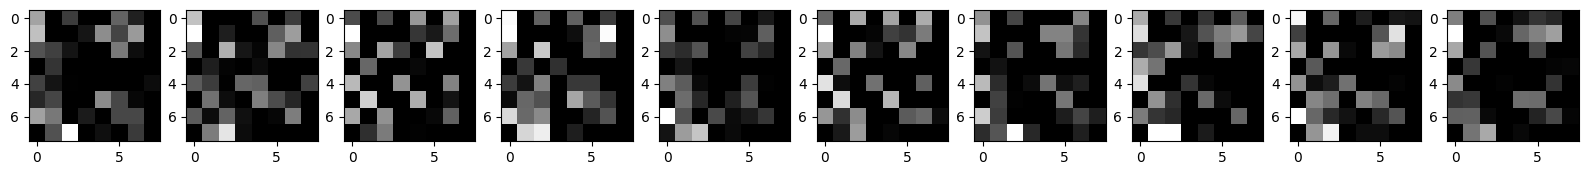

Reconstruction of Test Images


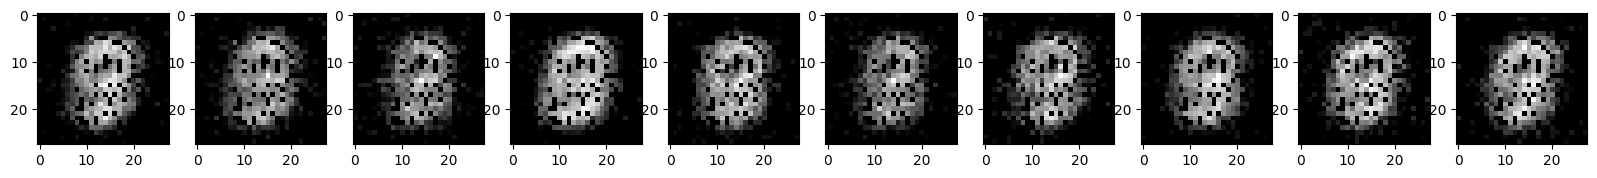

In [ ]:
comp = encoder.predict(X_test)
pred = autoencoder.predict(X_test)

plt.figure(figsize=(20, 4))
print("Test Images")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test[i].reshape((28, 28)), cmap='gray')
plt.show()

plt.figure(figsize=(20, 4))
print("Compressed Image")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(comp[i].reshape((8, 8)), cmap='gray')
plt.show()

plt.figure(figsize=(20, 4))
print("Reconstruction of Test Images")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(pred[i].reshape((28, 28)), cmap='gray')
plt.show()

Build a Autoencoder - Optimizer as SGD with Momentum

In [ ]:
# Encoder layers
X_input = Input(shape=(28, 28, 1))
encoder = Flatten()(X_input)
latent = Dense(64, activation="relu")(encoder)

# Decoder layers
decoder = Dense(64, activation="relu")(latent)
decoder = Dense(784, activation="relu")(decoder)
X_output = keras.layers.Reshape((28, 28, 1))(decoder)

# Encoder Model
encoder = Model(inputs = X_input, outputs = latent)

# Autoencoder model
autoencoder = Model(inputs = X_input, outputs = X_output)

# Compile the model
autoencoder.compile(loss='mean_squared_error', optimizer = SGD(momentum=0.9))

autoencoder.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,360 (411.56 KB)

 Trainable params: 105,360 (411.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = autoencoder.fit(X_train,
                          X_train,
                          batch_size=128,
                          epochs=50,
                          validation_split = 0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1023 - val_loss: 0.0846
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0813 - val_loss: 0.0758
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0754 - val_loss: 0.0740
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0739 - val_loss: 0.0730
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0729 - val_loss: 0.0720
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0719 - val_loss: 0.0707
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0704 - val_loss: 0.0691
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0687 - val_loss: 0.0673
Epoch 9/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0670 - val_loss: 0.0658
Epoch 10/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0654 - val_loss: 0.0642
Epoch 11/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0638 - val_loss: 0.0624
Epoch 12/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

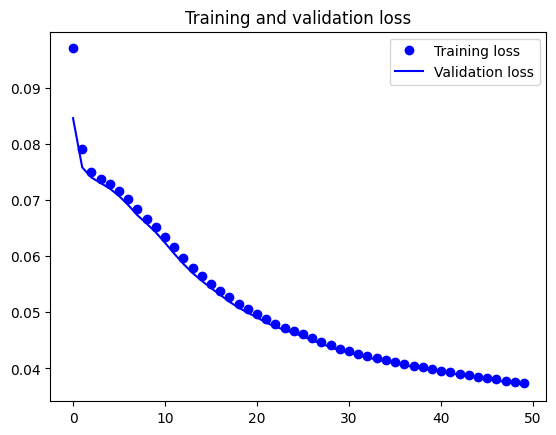

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(50)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Images


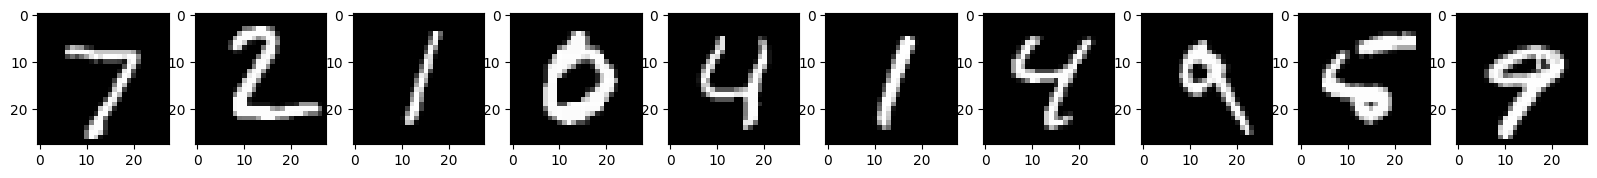

Compressed Image


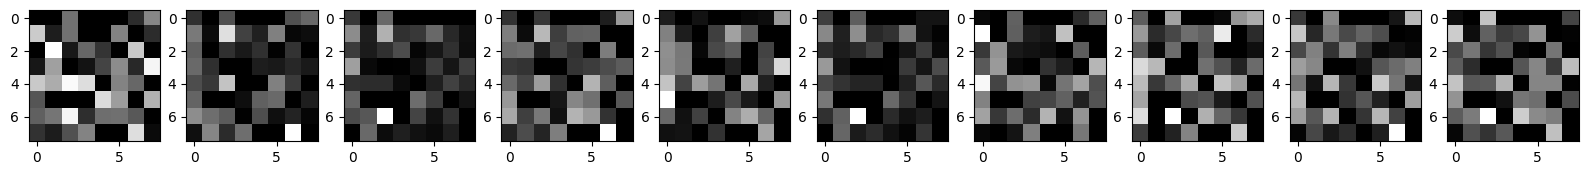

Reconstruction of Test Images


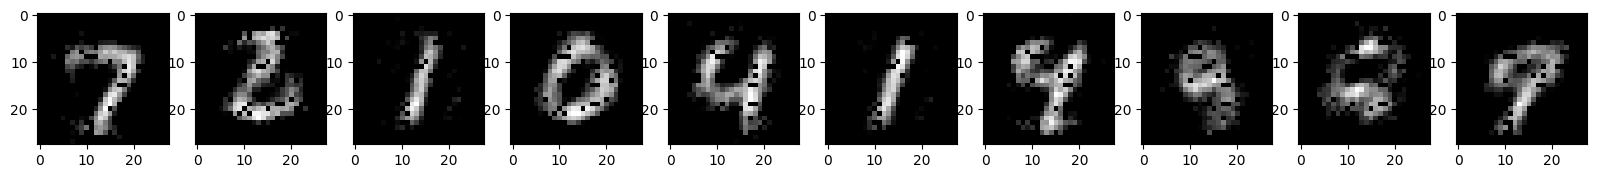

In [ ]:
comp = encoder.predict(X_test)
pred = autoencoder.predict(X_test)

plt.figure(figsize=(20, 4))
print("Test Images")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test[i].reshape((28, 28)), cmap='gray')
plt.show()

plt.figure(figsize=(20, 4))
print("Compressed Image")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(comp[i].reshape((8, 8)), cmap='gray')
plt.show()

plt.figure(figsize=(20, 4))
print("Reconstruction of Test Images")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(pred[i].reshape((28, 28)), cmap='gray')
plt.show()

Build a Autoencoder - Optimizer as Adagrad

In [ ]:
# Encoder layers
X_input = Input(shape=(28, 28, 1))
encoder = Flatten()(X_input)
latent = Dense(64, activation="relu")(encoder)

# Decoder layers
decoder = Dense(64, activation="relu")(latent)
decoder = Dense(784, activation="relu")(decoder)
X_output = keras.layers.Reshape((28, 28, 1))(decoder)

# Encoder Model
encoder = Model(inputs = X_input, outputs = latent)

# Autoencoder model
autoencoder = Model(inputs = X_input, outputs = X_output)

# Compile the model
autoencoder.compile(loss='mean_squared_error', optimizer = Adagrad())

autoencoder.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,360 (411.56 KB)

 Trainable params: 105,360 (411.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = autoencoder.fit(X_train,
                          X_train,
                          batch_size=128,
                          epochs=50,
                          validation_split = 0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1061 - val_loss: 0.1049
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1056 - val_loss: 0.1043
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1051 - val_loss: 0.1038
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1045 - val_loss: 0.1032
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1039 - val_loss: 0.1026
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1033 - val_loss: 0.1020
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1026 - val_loss: 0.1014
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1020 - val_loss: 0.1007
Epoch 9/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1012 - val_loss: 0.0999
Epoch 10/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1005 - val_loss: 0.0992
Epoch 11/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0997 - val_loss: 0.0984
Epoch 12/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

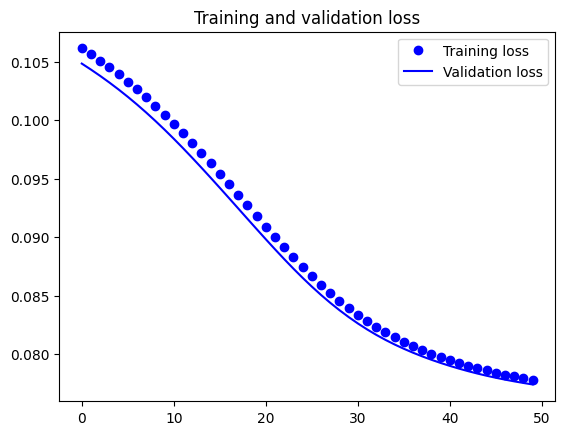

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(50)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Images


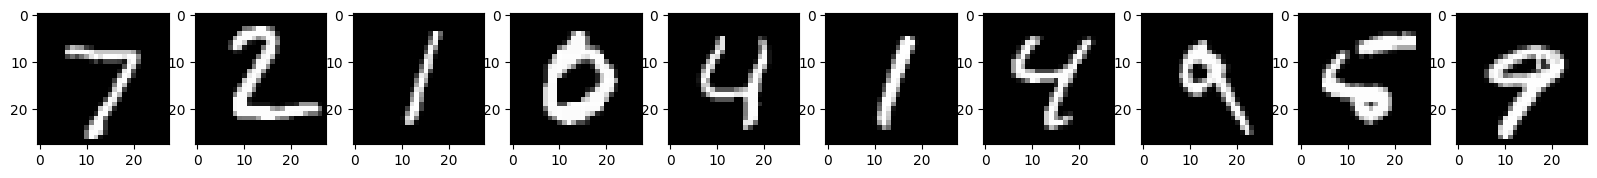

Compressed Image


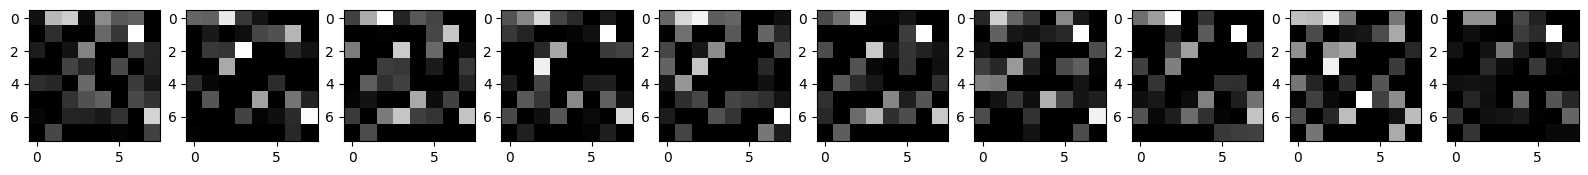

Reconstruction of Test Images


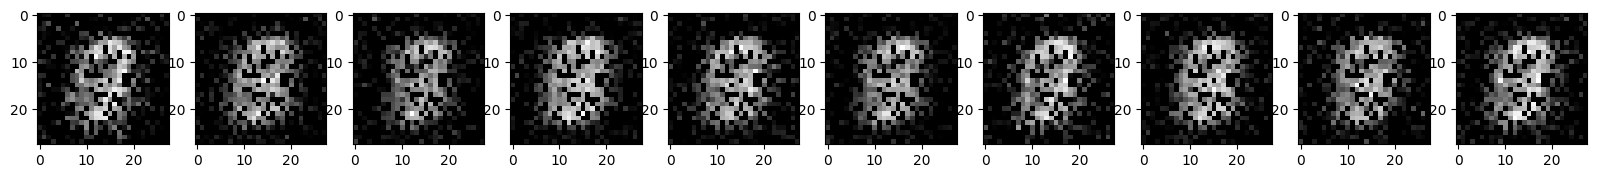

In [ ]:
comp = encoder.predict(X_test)
pred = autoencoder.predict(X_test)

plt.figure(figsize=(20, 4))
print("Test Images")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test[i].reshape((28, 28)), cmap='gray')
plt.show()

plt.figure(figsize=(20, 4))
print("Compressed Image")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(comp[i].reshape((8, 8)), cmap='gray')
plt.show()

plt.figure(figsize=(20, 4))
print("Reconstruction of Test Images")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(pred[i].reshape((28, 28)), cmap='gray')
plt.show()

Build a Autoencoder - Optimizer as RMSProp

In [ ]:
# Encoder layers
X_input = Input(shape=(28, 28, 1))
encoder = Flatten()(X_input)
latent = Dense(64, activation="relu")(encoder)

# Decoder layers
decoder = Dense(64, activation="relu")(latent)
decoder = Dense(784, activation="relu")(decoder)
X_output = keras.layers.Reshape((28, 28, 1))(decoder)

# Encoder Model
encoder = Model(inputs = X_input, outputs = latent)

# Autoencoder model
autoencoder = Model(inputs = X_input, outputs = X_output)

# Compile the model
autoencoder.compile(loss='mean_squared_error', optimizer = RMSprop())

autoencoder.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,360 (411.56 KB)

 Trainable params: 105,360 (411.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = autoencoder.fit(X_train,
                          X_train,
                          batch_size=128,
                          epochs=50,
                          validation_split = 0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0735 - val_loss: 0.0445
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0421 - val_loss: 0.0359
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0343 - val_loss: 0.0306
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0295 - val_loss: 0.0274
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0270 - val_loss: 0.0262
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0257 - val_loss: 0.0247
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0242 - val_loss: 0.0231
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0229 - val_loss: 0.0222
Epoch 9/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0221 - val_loss: 0.0218
Epoch 10/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0217 - val_loss: 0.0213
Epoch 11/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0211 - val_loss: 0.0210
Epoch 12/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

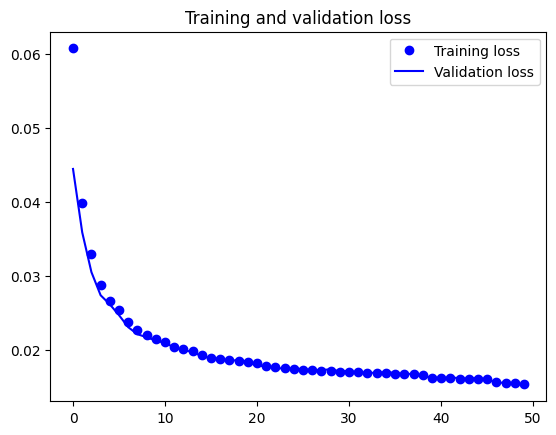

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(50)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Images


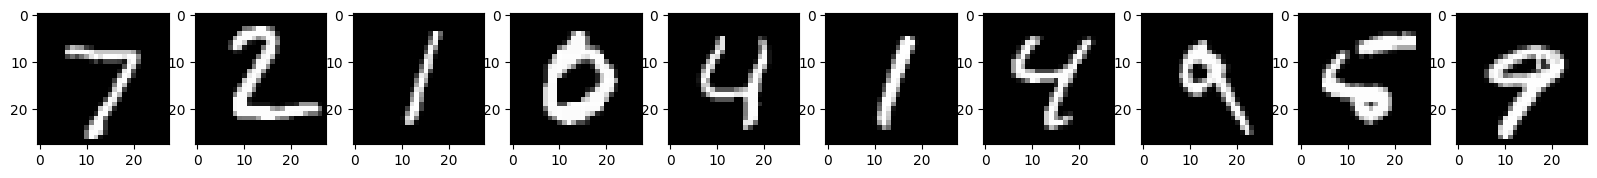

Compressed Image


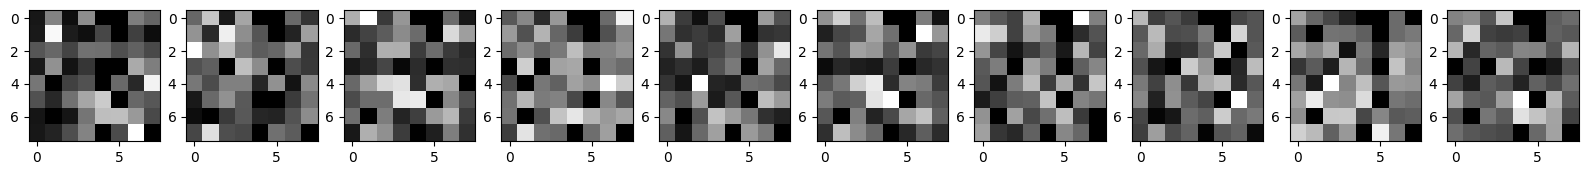

Reconstruction of Test Images


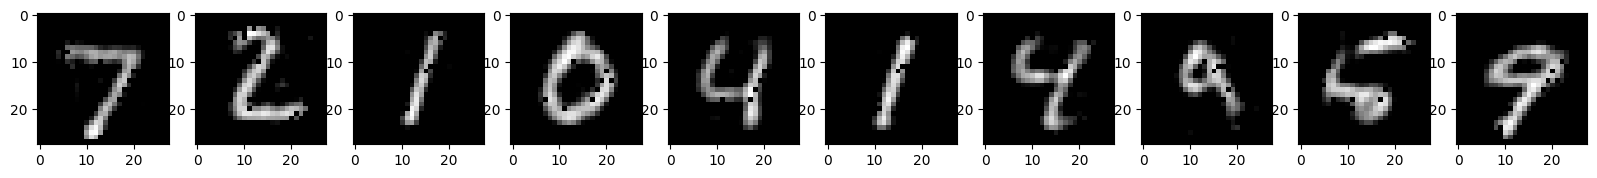

In [ ]:
comp = encoder.predict(X_test)
pred = autoencoder.predict(X_test)

plt.figure(figsize=(20, 4))
print("Test Images")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test[i].reshape((28, 28)), cmap='gray')
plt.show()

plt.figure(figsize=(20, 4))
print("Compressed Image")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(comp[i].reshape((8, 8)), cmap='gray')
plt.show()

plt.figure(figsize=(20, 4))
print("Reconstruction of Test Images")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(pred[i].reshape((28, 28)), cmap='gray')
plt.show()

Build a Autoencoder - Optimizer as Adam

In [ ]:
# Encoder layers
X_input = Input(shape=(28, 28, 1))
encoder = Flatten()(X_input)
latent = Dense(64, activation="relu")(encoder)

# Decoder layers
decoder = Dense(64, activation="relu")(latent)
decoder = Dense(784, activation="relu")(decoder)
X_output = keras.layers.Reshape((28, 28, 1))(decoder)

# Encoder Model
encoder = Model(inputs = X_input, outputs = latent)

# Autoencoder model
autoencoder = Model(inputs = X_input, outputs = X_output)

# Compile the model
autoencoder.compile(loss='mean_squared_error', optimizer = Adam())

autoencoder.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,360 (411.56 KB)

 Trainable params: 105,360 (411.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = autoencoder.fit(X_train,
                          X_train,
                          batch_size=128,
                          epochs=50,
                          validation_split = 0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0477 - val_loss: 0.0162
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0152 - val_loss: 0.0132
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0129 - val_loss: 0.0121
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0120 - val_loss: 0.0115
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0113 - val_loss: 0.0110
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0109 - val_loss: 0.0107
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0106 - val_loss: 0.0105
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0104 - val_loss: 0.0103
Epoch 9/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0102 - val_loss: 0.0101
Epoch 10/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0101 - val_loss: 0.0100
Epoch 11/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0099 - val_loss: 0.0099
Epoch 12/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

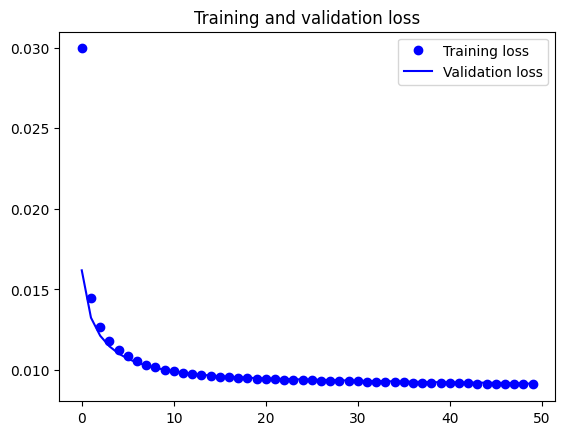

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(50)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Images


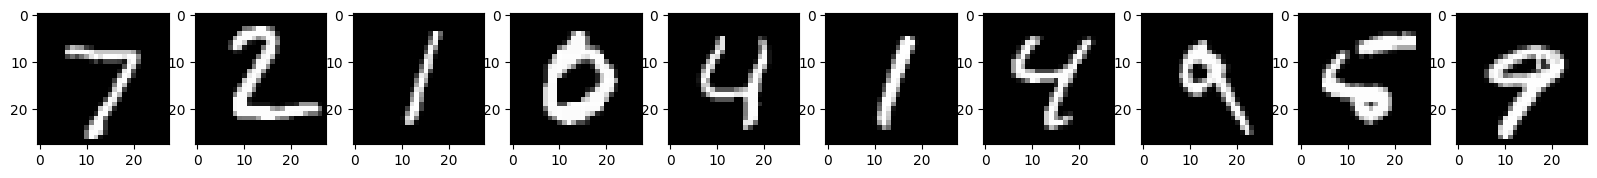

Compressed Image


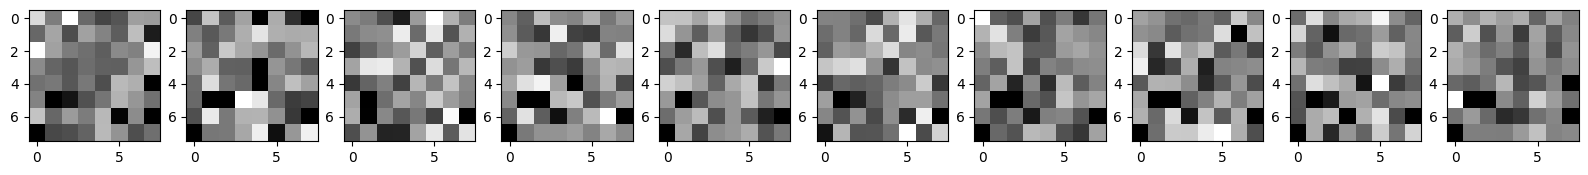

Reconstruction of Test Images


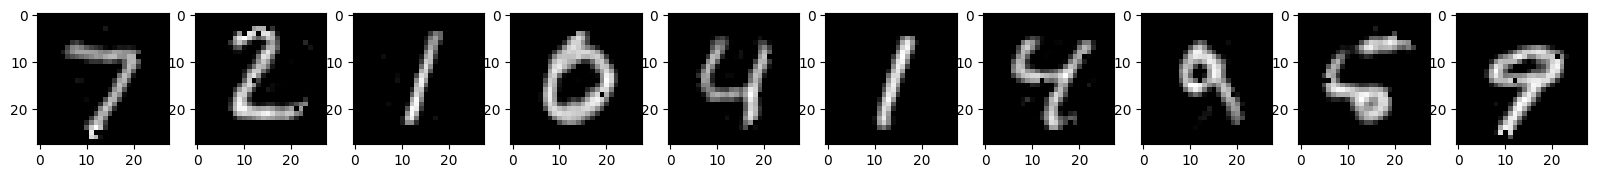

In [ ]:
comp = encoder.predict(X_test)
pred = autoencoder.predict(X_test)

plt.figure(figsize=(20, 4))
print("Test Images")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test[i].reshape((28, 28)), cmap='gray')
plt.show()

plt.figure(figsize=(20, 4))
print("Compressed Image")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(comp[i].reshape((8, 8)), cmap='gray')
plt.show()

plt.figure(figsize=(20, 4))
print("Reconstruction of Test Images")
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(pred[i].reshape((28, 28)), cmap='gray')
plt.show()

### CNN Autoencoder for Dimensionality Reduction

A **Convolutional Autoencoder (CNN-AE)** is a type of autoencoder that uses convolutional layers to learn compressed representations of images efficiently. It leverages the local connectivity patterns of images for better feature extraction and dimensionality reduction compared to fully connected layers.

#### Architecture

- **Encoder:**  
  Uses 2D convolutional layers to process an input image $ x \in \mathbb{R}^{H \times W \times C} $ and reduce its spatial dimensions (height and width) while learning feature maps.** The output is a lower-dimensional embedding of the original image.**

- **Decoder:**  
  Uses 2D transposed convolutional (also called deconvolutional) layers to **upsample the compressed representation** back to the original image size $ \hat{x} \in \mathbb{R}^{H \times W \times C} $, reconstructing the input.

- **The encoder-decoder pair is trained jointly to minimize reconstruction loss** (e.g., Mean Squared Error or Binary Crossentropy).
- For example, compress a $28 \times 28$ grayscale image into a $14 \times 14$ encoding by reducing spatial resolution by half via convolutional steps.
- This latent representation preserves important structures in fewer dimensions.

- Train the **autoencoder end-to-end on image datasets**:  
  $$
  \text{model.fit}(x_{train}, x_{train})
  $$
- After training, **use only the encoder part to obtain the reduced** (compressed) version of new images:
  $$
  z = \text{encoder.predict}(x_{test})
  $$

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Input, Conv2D, ZeroPadding2D, Conv2DTranspose
from keras.models import Model
from keras.optimizers import Adam
import matplotlib.pyplot as plt

Load data

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.
X_train.shape, X_test.shape

In [ ]:
# Build a CNN-autoencoder model.
x_input = Input(batch_shape=(None, *X_train.shape[1:], 1))

# Encoder
e_conv = Conv2D(filters=10,
                kernel_size=(3,3),
                padding = 'same',
                strides=2,
                activation='relu')(x_input)

# Decoder
d_conv = Conv2DTranspose(filters=10,
                         kernel_size=(3,3),
                         strides=2,
                         padding = 'same',
                         activation='relu')(e_conv)
x_output = Conv2D(filters=1,
                  kernel_size=(3,3),
                  strides=1,
                  padding = 'same',
                  activation='sigmoid')(d_conv)

autoencoder = Model(x_input, x_output)
encoder = Model(x_input, e_conv)
autoencoder.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.005))
autoencoder.summary()

In [ ]:
# Training
history = autoencoder.fit(x = X_train,
                          y = X_train,
                          epochs = 100,
                          shuffle = True,
                          batch_size=256,
                          validation_split = 0.2)

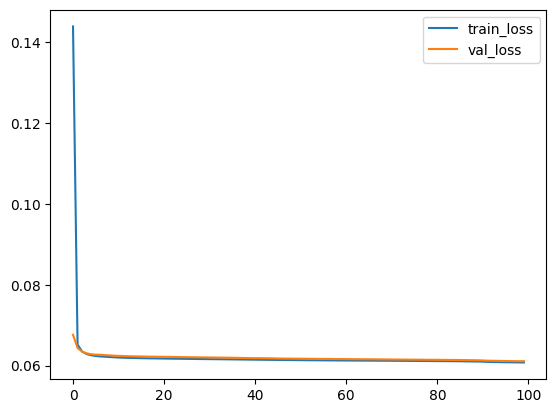

In [ ]:
# Loss History
plt.plot(history.history['loss'], label = 'train_loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()


Original images (28, 28)

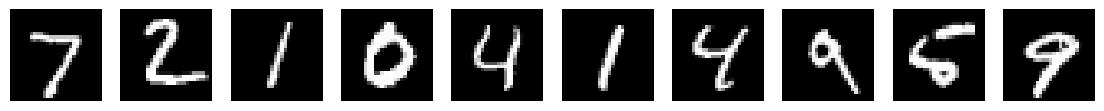

In [ ]:
# Visualize images
def show_image(x, n):
    plt.figure(figsize=(14, 4))
    for i in range(n):
        ax = plt.subplot(1, n, i+1)
        ax.imshow(x[i], cmap='gray')
        ax.axis('off')
    plt.show()

# Visualize the test images
n_img = 10
print("\nOriginal images (28, 28)", end='')
show_image(X_test, 10)


Reduced images (14, 14)

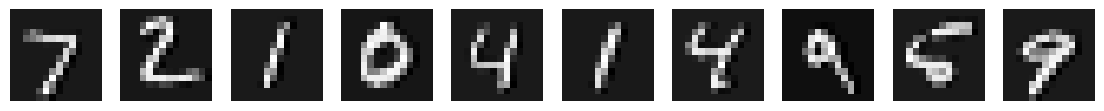

In [ ]:
# Visualize the reduced representation of x_test
r_test = encoder.predict(X_test, verbose=0)
print("\nReduced images (14, 14)", end='')
show_image(r_test.mean(axis=3), 10)

## Denoising Autoencoders

When training neural networks, relying solely on the original dataset limits the model’s ability to generalize.
- Intuitively, variations of an input remain semantically the same (e.g., an upside-down dog, or a dog shifted in different parts of an image).
  - Incorporating these variations explicitly in the training data enhances model robustness.
- Beyond simple geometric transformations (shift, rotate, flip), **adding noise** is another effective data augmentation strategy.
- Two common noise types:
  - **Gaussian noise:** Random normal noise added to input features.
  - **Masking noise:** Randomly setting a portion of the input features to zero (element-wise multiplication with binary mask). Typical zeroing probability ranges from 10% up to 50%, with effective regularization observed up to 50%.

- Denoising autoencoders trained on corrupted inputs learn more generalizable and robust features.
  - DAE learns to map **noisy inputs** $\tilde{\mathbf{x}}$
 to **clean outputs** ${\mathbf{x}}$.
- This approach improves model performance on unseen or noisy data.
- This forces the model to discover robust features representing the underlying data distribution, not noise artifacts.

In [ ]:
import keras
from keras.datasets import fashion_mnist
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [ ]:
# Load a FashionMNIST dataset
(X, y), (X_test, y_test) = fashion_mnist.load_data()
# X = X / 255

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
X.shape, y.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

Add noise to images

In [ ]:
X.shape

(60000, 28, 28)

In [ ]:
batch = np.expand_dims(X[:30, :, :], axis = -1)
batch.shape

(30, 28, 28, 1)

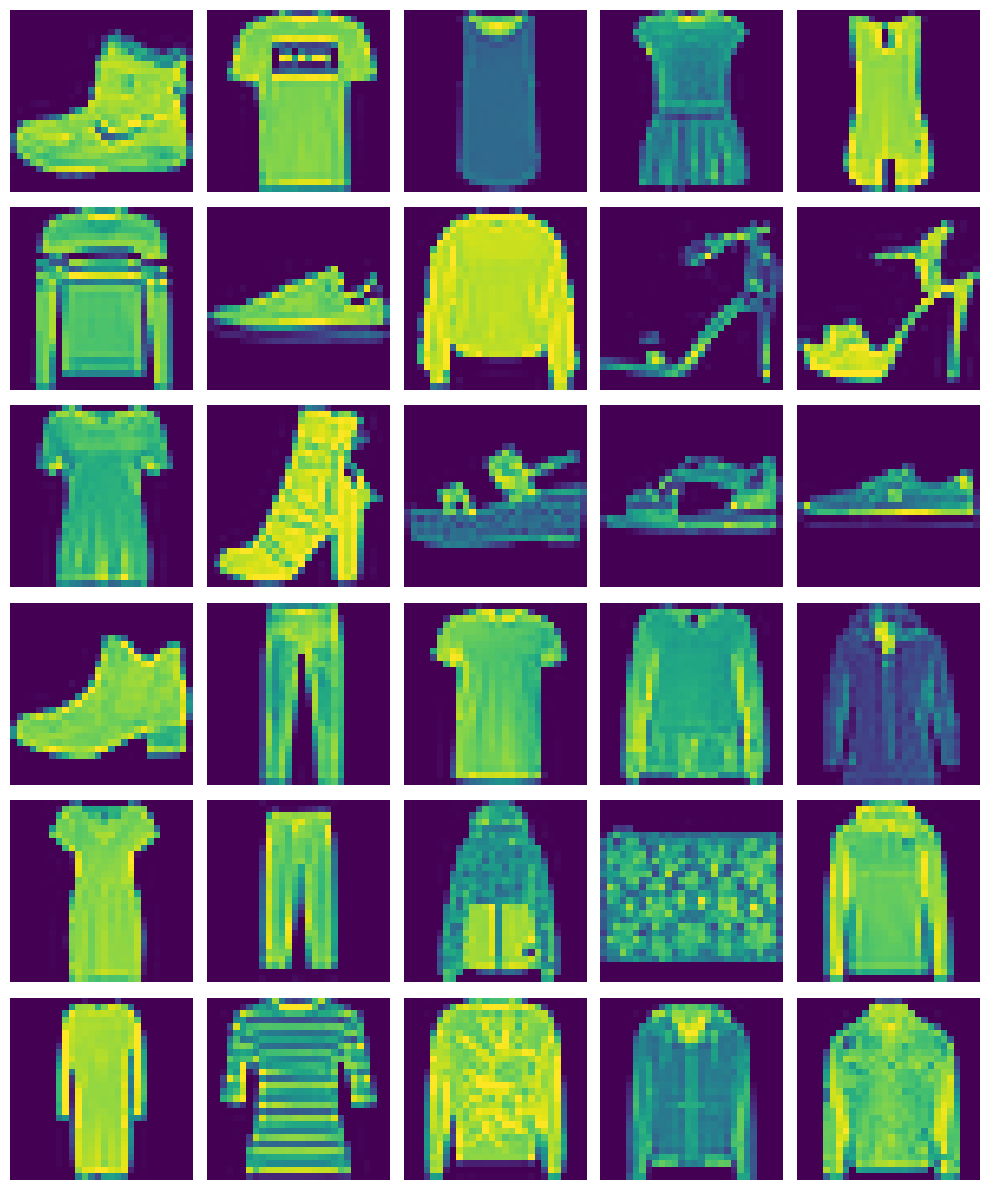

In [ ]:
# Before adding noise
keras.visualization.plot_image_gallery(batch)

In [ ]:
# After adding noise
X_noise = X + 0.3 * np.random.normal(size=X.shape)
X_noise = np.clip(X_noise, 0., 1.)
X_noise = X_noise.reshape(-1, 28, 28, 1)
X_noise.shape

(60000, 28, 28, 1)

In [ ]:
batch_noise = X_noise[:30, :, :]
batch_noise.shape

(30, 28, 28, 1)

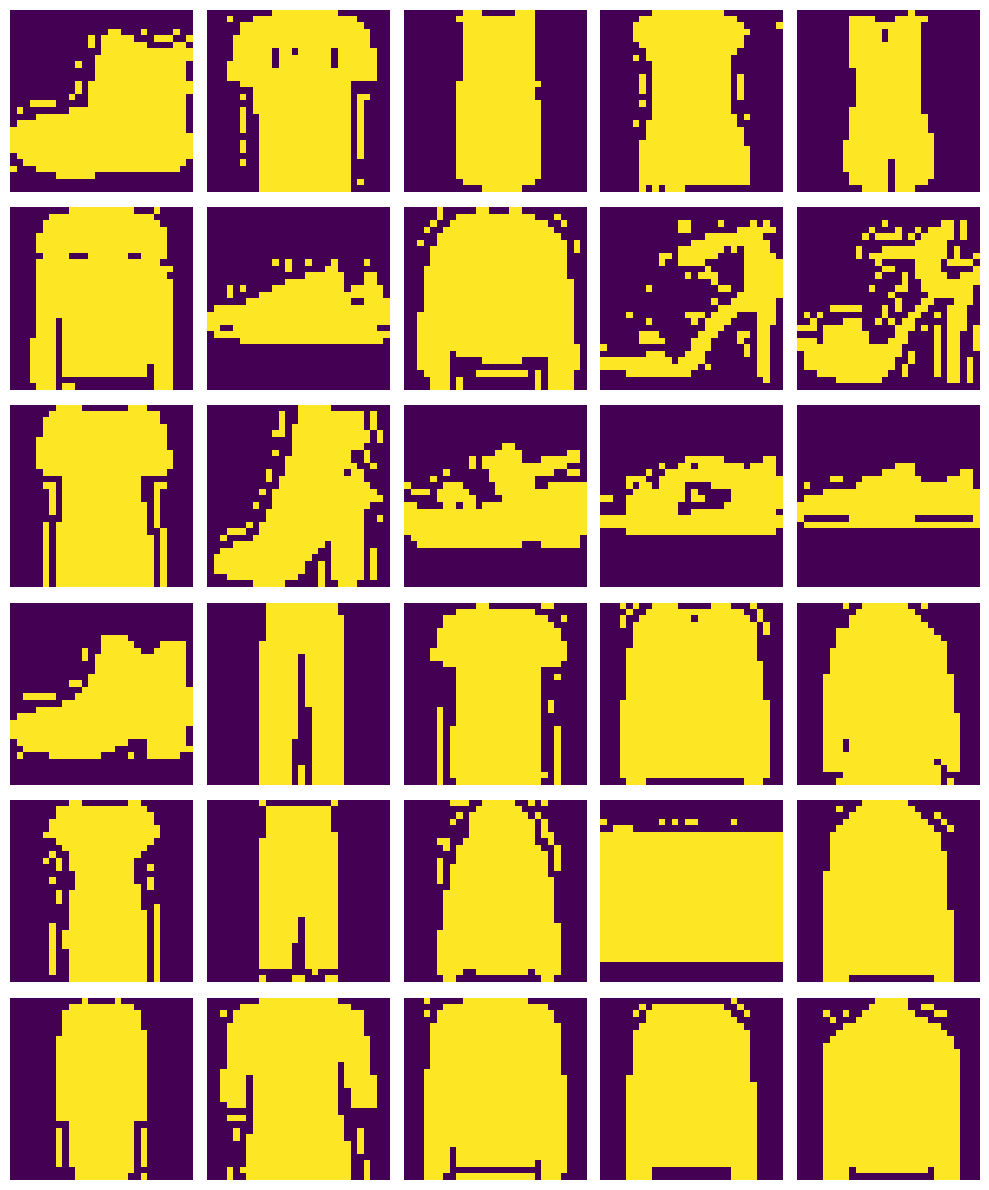

In [ ]:
keras.visualization.plot_image_gallery(batch_noise)

In [ ]:
X_orig = X.reshape(-1, 28, 28, 1)
X_orig.shape

(60000, 28, 28, 1)

Apply circular motion Blur

In [ ]:
kernel = cv2.circle(np.zeros((10, 10)),
                    center = (5,5),
                    radius = 3,
                    color = (255,),
                    thickness = -1)
X_blur = [cv2.filter2D(img, -1, kernel) for img in X]
X_blur = np.array(X_blur)
X_blur = np.expand_dims(X_blur, -1)
X_blur.shape

(60000, 28, 28, 1)

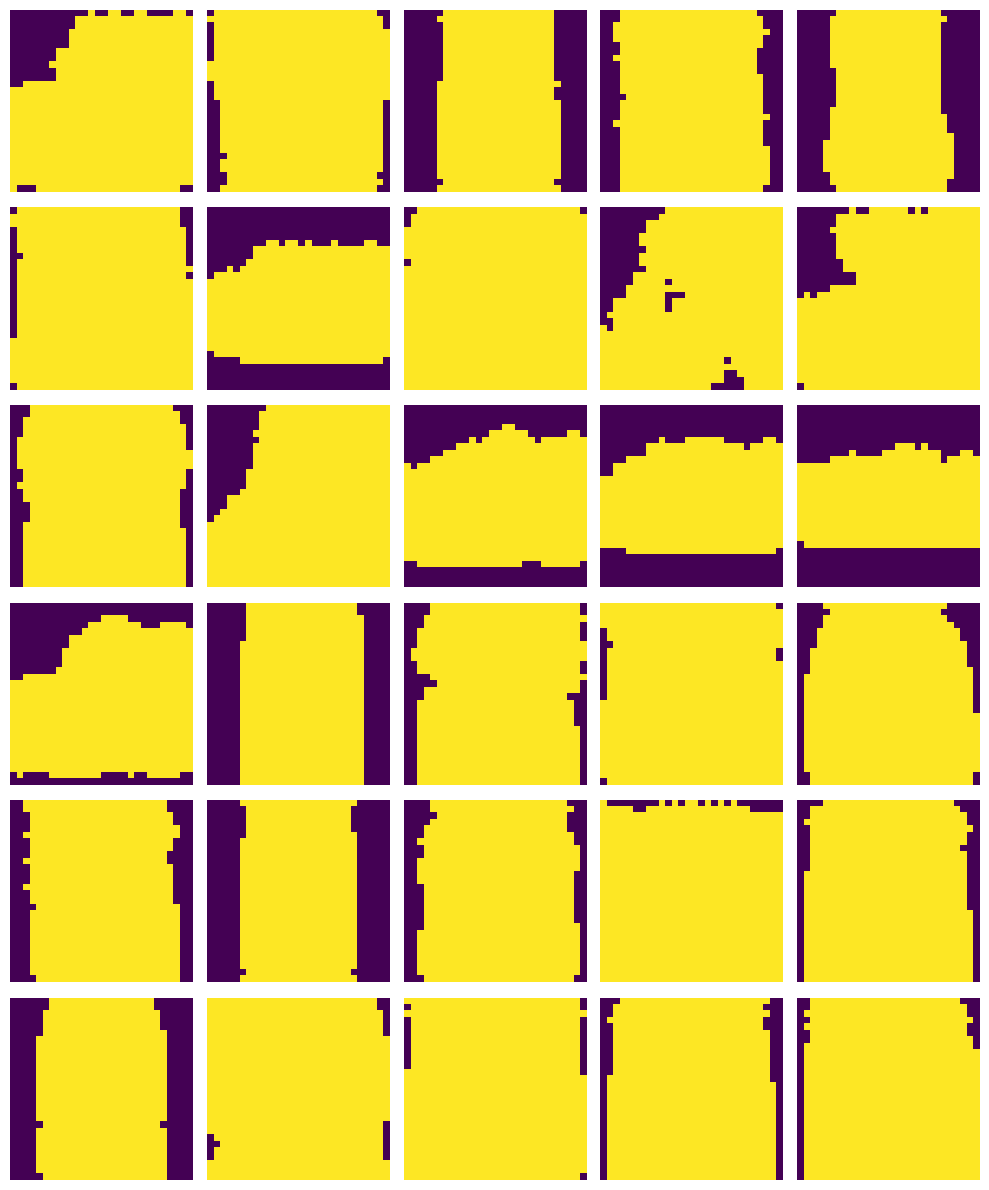

In [ ]:
keras.visualization.plot_image_gallery(X_blur[:30,:,:])

Denoising FashionMNIST

In [ ]:
import numpy as np
import keras
from keras.layers import Input, Conv2D, MaxPooling2D
from keras.layers import Conv2DTranspose
from keras.models import Model
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_noise, X_orig, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((45000, 28, 28, 1),
 (15000, 28, 28, 1),
 (45000, 28, 28, 1),
 (15000, 28, 28, 1))

In [ ]:
X_train, X_test, y_train, y_test = X_train/255, X_test/255, y_train/255, y_test/255

In [ ]:
# CNN AutoEncoder.
# Encoder
x_input = Input(batch_shape=(None, *X_train.shape[1:]))
e_conv = Conv2D(10, (3,3), strides=1,
                padding = 'same', activation='relu')(x_input)

# Decoder
d_conv = Conv2DTranspose(10, (3,3), strides=1,
                padding = 'same', activation='relu')(e_conv)
x_output = Conv2D(filters=1, kernel_size=(3,3), strides=1,
                padding = 'same', activation='sigmoid')(d_conv)

model = Model(x_input, x_output)
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.005))
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 10)     │           910 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │            91 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101 (4.30 KB)

 Trainable params: 1,101 (4.30 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Tranining
h = model.fit(X_train, y_train, epochs = 100, batch_size=300,
              validation_data=[X_test, y_test])

Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.6038 - val_loss: 0.3608
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3478 - val_loss: 0.3312
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3290 - val_loss: 0.3263
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3242 - val_loss: 0.3226
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3214 - val_loss: 0.3193
Epoch 6/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3184 - val_loss: 0.3168
Epoch 7/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3175 - val_loss: 0.3161
Epoch 8/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3147 - val_loss: 0.3140
Epoch 9/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3131 - val_loss: 0.3132
Epoch 10/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3125 - val_loss: 0.3123
Epoch 11/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3123 - val_loss: 0.3118
Epoch 12/100
150/150 ━━━━━━━━━━━━━━━━━━━

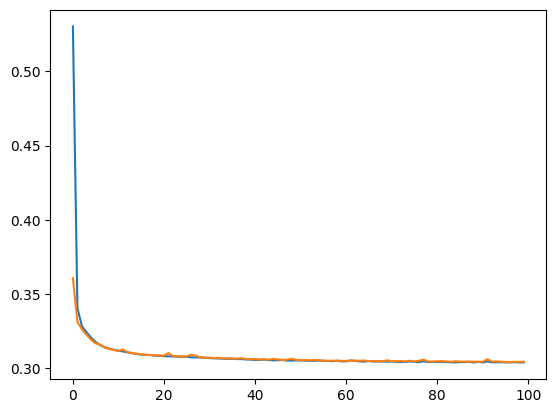

In [ ]:
# Loss History
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])
plt.show()

In [ ]:
# Denoising x_test
X_pred = model.predict(X_test, verbose=0)

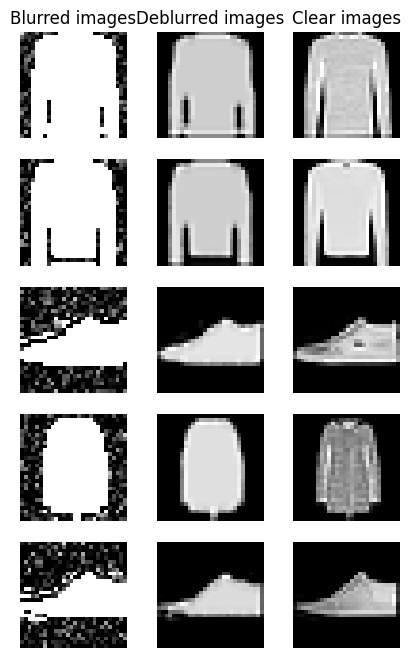

In [ ]:
# Visualize x_test and x_pred to see how much noise has been removed.
n = 5
idx = np.random.choice(X_test.shape[0], n)
fig, ax = plt.subplots(n, 3, figsize=(5, 8))

for i, k in enumerate(idx):
    ax[i, 0].imshow(X_test[k], cmap='gray')
    ax[i, 1].imshow(X_pred[k], cmap='gray')
    ax[i, 2].imshow(y_test[k], cmap='gray')
    ax[i, 0].axis('off')
    ax[i, 1].axis('off')
    ax[i, 2].axis('off')

    if i == 0:
        ax[i, 0].set_title("Blurred images")
        ax[i, 1].set_title("Deblurred images")
        ax[i, 2].set_title("Clear images")
plt.show()

Deblurring the FashionMNIST

In [ ]:
import numpy as np
import keras
from keras.layers import Input, Conv2D, MaxPooling2D
from keras.layers import Conv2DTranspose
from keras.models import Model
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_blur, X_orig, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((45000, 28, 28, 1),
 (15000, 28, 28, 1),
 (45000, 28, 28, 1),
 (15000, 28, 28, 1))

In [ ]:
X_train, X_test, y_train, y_test = X_train/255, X_test/255, y_train/255, y_test/255

In [ ]:
# CNN AutoEncoder.
# Encoder
x_input = Input(batch_shape=(None, *X_train.shape[1:]))
e_conv = Conv2D(10, (3,3), strides=1,
                padding = 'same', activation='relu')(x_input)

# Decoder
d_conv = Conv2DTranspose(10, (3,3), strides=1,
                padding = 'same', activation='relu')(e_conv)
x_output = Conv2D(filters=1, kernel_size=(3,3), strides=1,
                padding = 'same', activation='sigmoid')(d_conv)

model = Model(x_input, x_output)
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.005))
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 10)     │           910 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │            91 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101 (4.30 KB)

 Trainable params: 1,101 (4.30 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Tranining
h = model.fit(X_train, y_train, epochs = 300, batch_size=300,
              validation_data=[X_test, y_test])

Epoch 1/300
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.3859 - val_loss: 0.3860
Epoch 2/300
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3872 - val_loss: 0.3862
Epoch 3/300
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3864 - val_loss: 0.3860
Epoch 4/300
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3866 - val_loss: 0.3859
Epoch 5/300
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3867 - val_loss: 0.3858
Epoch 6/300
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3859 - val_loss: 0.3858
Epoch 7/300
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3867 - val_loss: 0.3859
Epoch 8/300
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3871 - val_loss: 0.3860
Epoch 9/300
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3872 - val_loss: 0.4117
Epoch 10/300
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4001 - val_loss: 0.3881
Epoch 11/300
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3882 - val_loss: 0.3868
Epoch 12/300
150/150 ━━━━━━━━━━━━━━━━━━

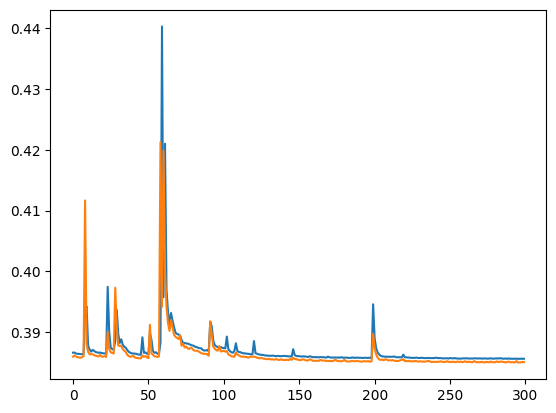

In [ ]:
# Loss History
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])
plt.show()

In [ ]:
# Denoising x_test
X_pred = model.predict(X_test, verbose=0)

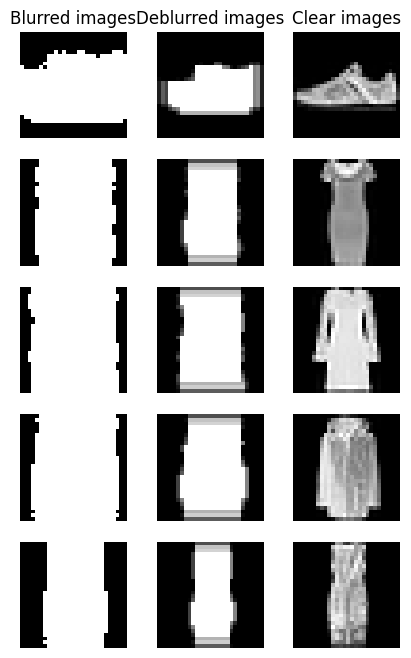

In [ ]:
# Visualize x_test and x_pred to see how much noise has been removed.
n = 5
idx = np.random.choice(X_test.shape[0], n)
fig, ax = plt.subplots(n, 3, figsize=(5, 8))

for i, k in enumerate(idx):
    ax[i, 0].imshow(X_test[k], cmap='gray')
    ax[i, 1].imshow(X_pred[k], cmap='gray')
    ax[i, 2].imshow(y_test[k], cmap='gray')
    ax[i, 0].axis('off')
    ax[i, 1].axis('off')
    ax[i, 2].axis('off')

    if i == 0:
        ax[i, 0].set_title("Blurred images")
        ax[i, 1].set_title("Deblurred images")
        ax[i, 2].set_title("Clear images")
plt.show()